<a href="https://colab.research.google.com/github/LuizGustavoReis/am-t4-s1a2026/blob/main/multineuralCensus0512.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes| Disgest GaussianNB [Fase 1 - census_data]

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar digest de base_credit

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
 X_census_treinameto , Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinameto.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [8]:
from sklearn.naive_bayes import GaussianNB

In [9]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_treinameto, Y_census_treinamento)

GaussianNB()

In [10]:
census_predict = naive_census_data.predict(X_census_teste)

In [11]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [12]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [15]:
confusion_matrix(Y_census_teste, census_predict)


array([[1172, 2521],
       [  35, 1157]])

In [16]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

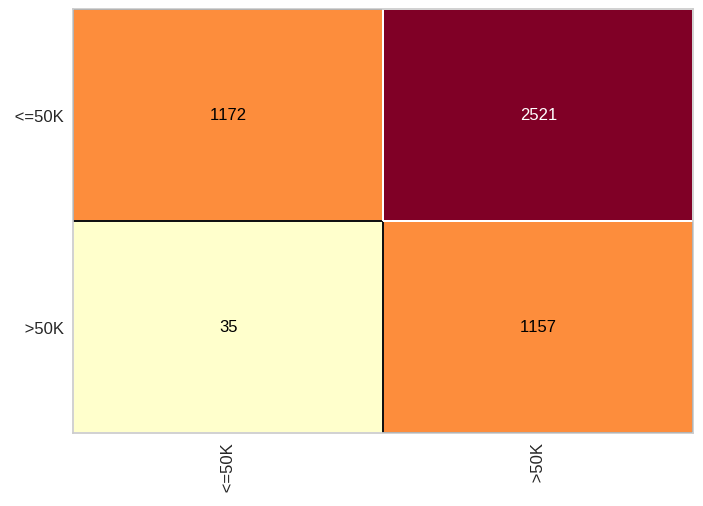

In [17]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_treinameto, Y_census_treinamento)

cm_census.score(X_census_teste, Y_census_teste)

#Pipeline Arvore de Decisão [Fase 2 - census_data]

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_treinameto, Y_census_treinamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [20]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy', max_depth=None, max_features = None, max_leaf_nodes=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0,
                        random_state=0,splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [21]:
previsoes_arvore = arvore_census_data.predict(X_census_teste)

In [22]:
previsoes_arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [23]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [25]:
accuracy_score(Y_census_teste, previsoes_arvore)

0.8104401228249745

In [26]:
from yellowbrick.classifier import ConfusionMatrix

In [27]:
print(classification_report(Y_census_teste, previsoes_arvore))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



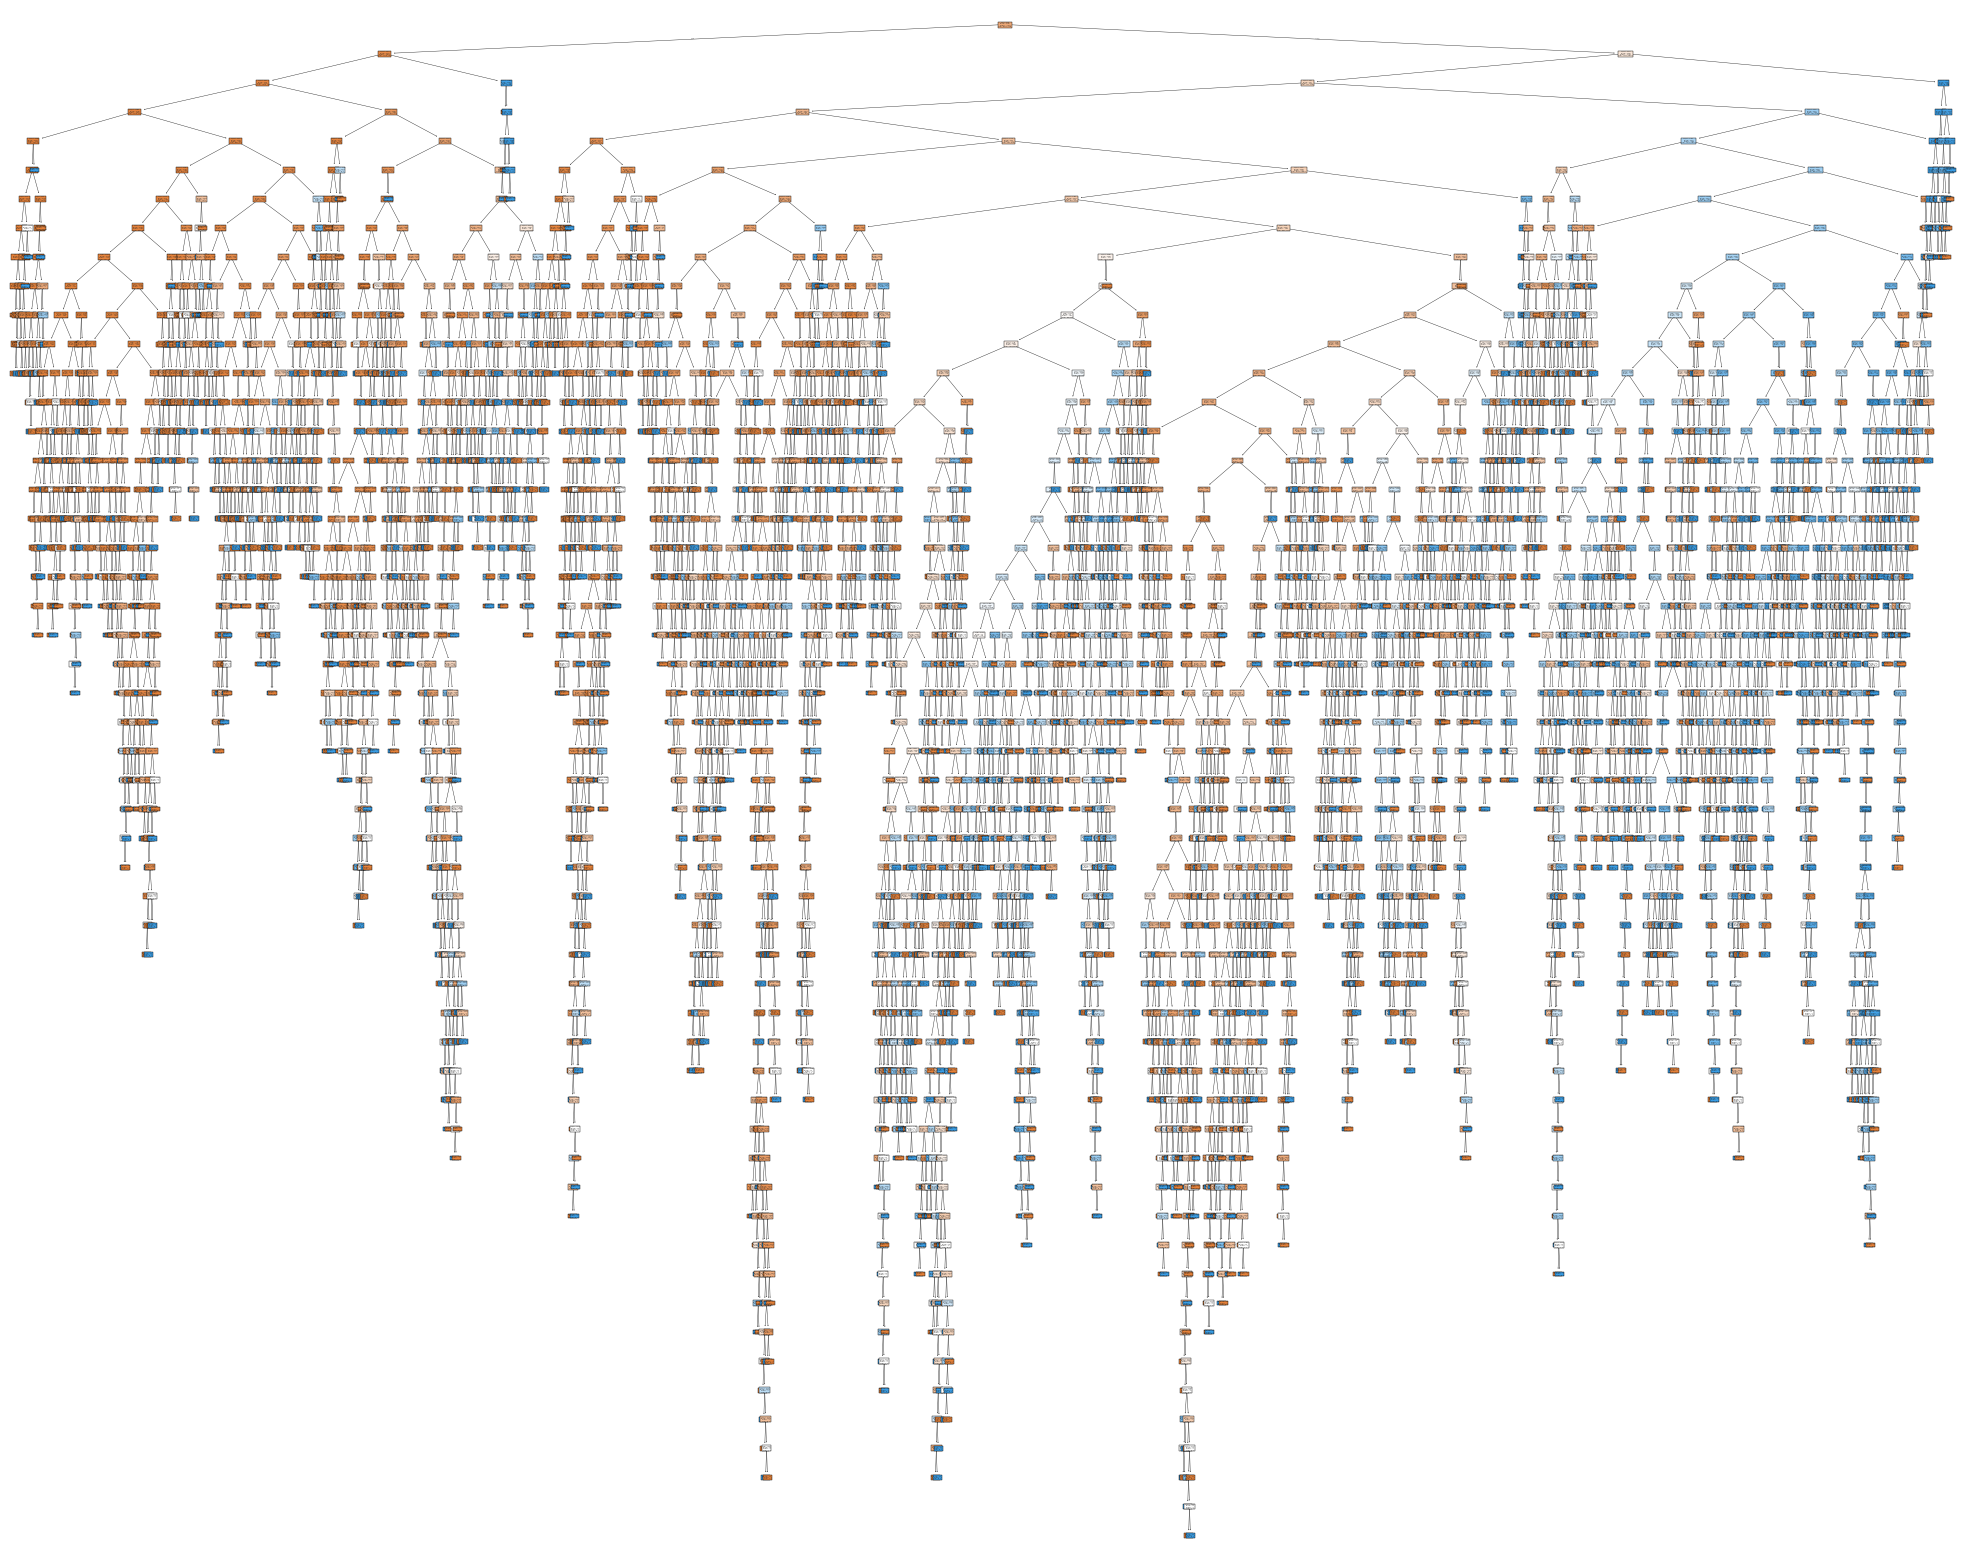

In [32]:
from sklearn import tree
import matplotlib.pyplot as plt
.
fig = plt.figure(figsize=(25,20))


tree.plot_tree(arvore_census_data, filled=True)
plt.show()

#